**A Hybrid Method**

Numerical methods and deep learning can often complement each other when solving differential equations. A common strategy is to first approximate the solution with Euler's method and then refine it using a neural network.
We shall implement this method in the case of the simple ODE
$$\frac{dy}{dt} = y, \quad y(0) = 1,  $$
for which the exact solution is known, $y_{\rm exact} (t) =  e^t$.


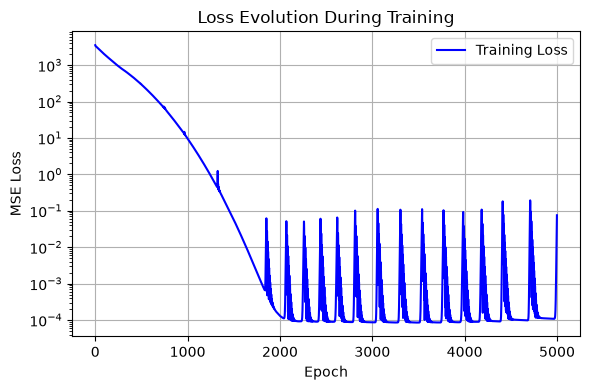

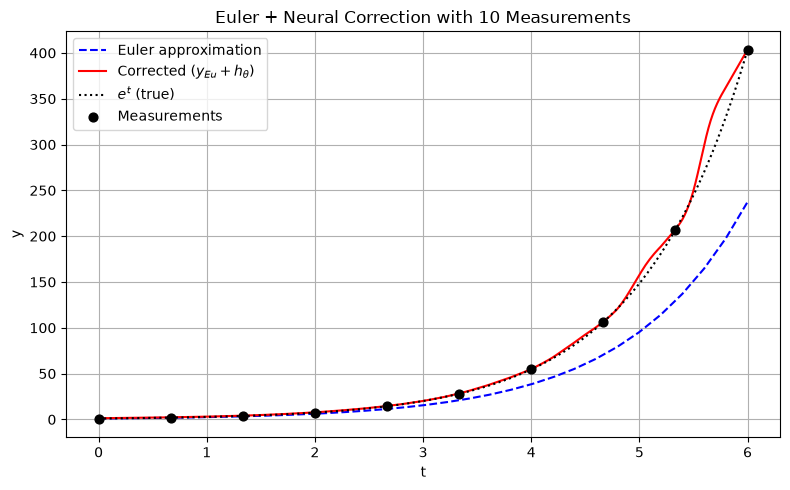

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1) Define domain and true solution
t_final = 6.0
dt = 0.2
t_eu = np.arange(0, t_final + dt, dt, dtype=np.float32)
y_true = np.exp(t_eu)

# 2) Euler approximation y_Eu on full grid
y_eu = np.zeros_like(t_eu)
y_eu[0] = 1.0
for i in range(len(t_eu)-1):
    y_eu[i+1] = y_eu[i] + dt * y_eu[i]

# 3) Measurements at 10 equidistant points
t_meas = np.linspace(0, t_final, 10, dtype=np.float32)
y_meas = np.exp(t_meas)
y_eu_meas = np.interp(t_meas, t_eu, y_eu)

# 4) Prepare training data: inputs = t_meas, targets = correction
t_train = torch.tensor(t_meas.reshape(-1, 1), dtype=torch.float32)
correction = torch.tensor(
    (y_meas - y_eu_meas).reshape(-1, 1),
    dtype=torch.float32
)

# 5) Build correction network h_theta(t)
class CorrectionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model_h = CorrectionNet()

# 6) Compile and train on measurement data, saving history
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_h.parameters(), lr=1e-2)

history = []

epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    pred = model_h(t_train)
    loss = criterion(pred, correction)

    loss.backward()
    optimizer.step()

    history.append(loss.item())

# 7) Plot loss evolution vs. epochs
plt.figure(figsize=(6,4))
plt.plot(history, 'b-', label='Training Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Evolution During Training')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 8) Evaluate on fine grid
t_fine = np.linspace(0, t_final, 300, dtype=np.float32).reshape(-1,1)
y_eu_fine = np.interp(t_fine.flatten(), t_eu, y_eu)

t_fine_tensor = torch.tensor(t_fine, dtype=torch.float32)

model_h.eval()
with torch.no_grad():
    h_pred = model_h(t_fine_tensor).numpy()

y_corr = y_eu_fine.reshape(-1,1) + h_pred
y_true_fine = np.exp(t_fine)

# 9) Plot results
plt.figure(figsize=(8,5))
plt.plot(t_fine, y_eu_fine, 'b--', label='Euler approximation')
plt.plot(t_fine, y_corr, 'r-', label='Corrected ($y_{Eu}+h_\\theta$)')
plt.plot(t_fine, y_true_fine, 'k:', label='$e^t$ (true)')
plt.scatter(t_meas, y_meas, color='black', s=40, zorder=5, label='Measurements')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.title('Euler + Neural Correction with 10 Measurements')
plt.grid()
plt.tight_layout()
plt.show()